In [33]:
import pandas as pd

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [34]:
# train 데이터셋의 전체적인 내용 파악
# train 데이터셋의 모양 파악
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [35]:
# train 데이터셋의 정보 확인
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [36]:
# 데이터셋 결측치 확인
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [37]:
# Age 결측치 평균값으로 대체 & Embarked 결측치 최빈값으로 대체
df_train["Age"].fillna(df_train["Age"].mean(), inplace = True)
df_train["Embarked"].fillna(df_train["Embarked"].mode()[0], inplace = True)

# Cabin 열 삭제
df_train = df_train.drop("Cabin", axis = 1)

display(df_train.head())
df_train.isnull().sum()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32336\3773406769.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["Age"].fillna(df_train["Age"].mean(), inplace = True)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32336\3773406769.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 데이터 인코딩

---
범주형 변수 인코딩

In [38]:
# OneHotEncoder 사용
# get_dummies를 사용하면 어떻게 되는가?

from sklearn.preprocessing import OneHotEncoder

# Encoder 객체 생성
encoder = OneHotEncoder(sparse_output=False)

# 대상 컬럼 추출 및 변환
target = ["Sex", "Embarked"]
encoded = encoder.fit_transform(df_train[target])

# 변환 데이터 DF로 만들고 컬럼명 지정
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(target))

# 기존 데이터프레임과 결합 및 원본 컬럼 삭제
df_train = pd.concat([df_train.drop(target, axis=1), encoded_df], axis=1)

In [39]:
display(df_train.head())
df_train.info()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,0.0,1.0,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1.0,0.0,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1.0,0.0,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1.0,0.0,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,0.0,1.0,0.0,0.0,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Sex_female   891 non-null    float64
 10  Sex_male     891 non-null    float64
 11  Embarked_C   891 non-null    float64
 12  Embarked_Q   891 non-null    float64
 13  Embarked_S   891 non-null    float64
dtypes: float64(7), int64(5), object(2)
memory usage: 97.6+ KB


## 데이터 스케일링
---
- StandardScaler 사용
- 수치형 변수를 평균 0, 표준편챠 1로 변환
- id나 범주형 변수는 스케일링 대상에서 제외

In [40]:
from sklearn.preprocessing import StandardScaler

# 스케일링 컬럼 선택
scaling_cols = ["Age", "Fare"]

# StandardScaler 객체 생성
scaler = StandardScaler()

# 스케일링 시행 및 원본 업데이트
df_train[scaling_cols] = scaler.fit_transform(df_train[scaling_cols])

df_train.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",-0.592481,1,0,A/5 21171,-0.502445,0.0,1.0,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.638789,1,0,PC 17599,0.786845,1.0,0.0,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",-0.284663,0,0,STON/O2. 3101282,-0.488854,1.0,0.0,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.407926,1,0,113803,0.420730,1.0,0.0,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",0.407926,0,0,373450,-0.486337,0.0,1.0,0.0,0.0,1.0


## 데이터 왜도

In [41]:
from scipy.stats import skew

# 수치형 컬럼 선택
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]

# 왜도 계산
skewness = df_train[numeric_cols].skew().sort_values(ascending=False)
skew_df = pd.DataFrame({"Skewness" : skewness})

skew_df

,Skewness
Fare,4.787317
SibSp,3.695352
Parch,2.749117
Age,0.434488


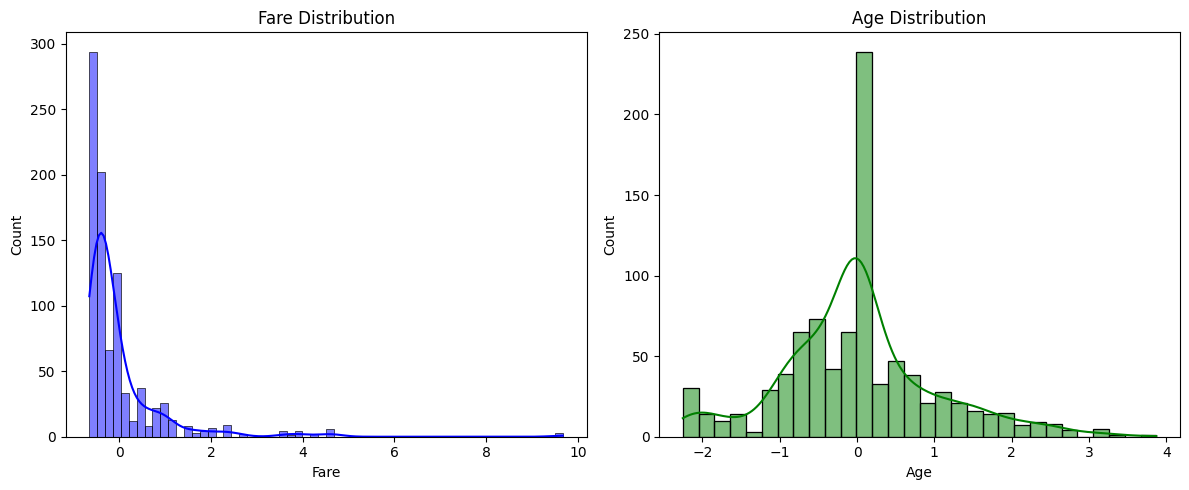

In [42]:
# 시각화로 왜도 분석

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Fare 분포
plt.subplot(1, 2, 1)
sns.histplot(df_train["Fare"], kde=True, color="blue")
plt.title("Fare Distribution")

# Age 분포
plt.subplot(1, 2, 2)
sns.histplot(df_train["Age"], kde=True, color="green")
plt.title("Age Distribution")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'After Log Transform')

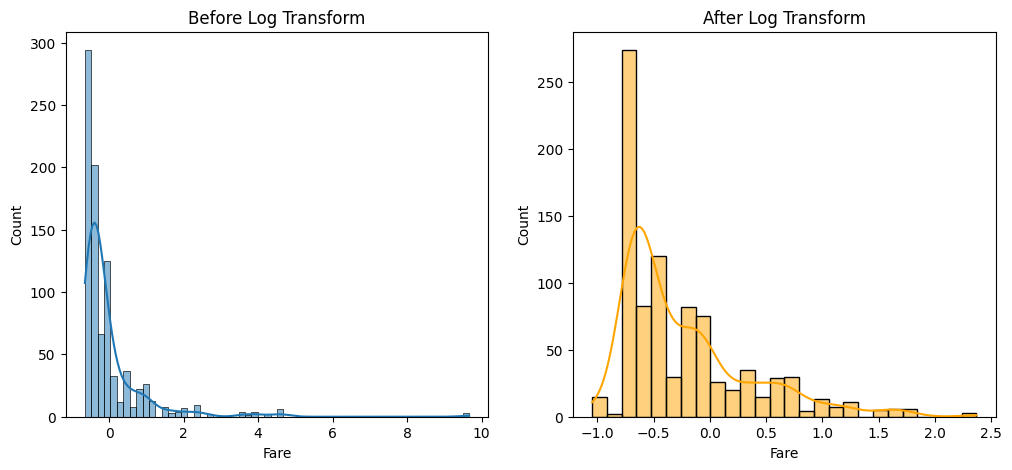

In [43]:
# 왜도 처리

import numpy as np

# 로그 변환 적용
fare_log = np.log1p(df_train["Fare"])

# 변환 전후 비교 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_train['Fare'], kde=True)
plt.title("Before Log Transform")

plt.subplot(1, 2, 2)
sns.histplot(fare_log, kde=True, color='orange')
plt.title(f"After Log Transform")

## 이상치 탐색 및 처리

In [44]:
# 이상치 탐색

from numpy._core.defchararray import upper

def get_outlier(df, column):
  Q1 = np.percentile(df[column], 25)
  Q3 = np.percentile(df[column], 75)

  IQR = Q3 - Q1

  lower_bound = Q1-1.5*IQR
  upper_bound = Q3+1.5*IQR

  outlier_indices = df[(df[column] < lower_bound) | (df[column] > upper_bound)].index

  print(f"{column}의 경계값: [{lower_bound:.2f}, {upper_bound:.2f}]")
  print(f"{column}의 이상치 개수: {len(outlier_indices)}")

  return outlier_indices

# Age & Fare 이상치 확인
age_outliers = get_outlier(df_train, 'Age')
fare_outliers = get_outlier(df_train, 'Fare')

Age의 경계값: [-2.09, 1.91]
Age의 이상치 개수: 66
Fare의 경계값: [-1.19, 0.67]
Fare의 이상치 개수: 116


In [45]:
# 이상치 처리
# 경계값 고정 방식(Capping) 사용

def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 경계값을 벗어나는 데이터를 경계값으로 대체 (Capping)
    df[column] = np.where(df[column] > upper_bound, upper_bound,
                          np.where(df[column] < lower_bound, lower_bound, df[column]))
    return df

# 이상치 처리 적용
df_train = handle_outliers(df_train, 'Age')
df_train = handle_outliers(df_train, 'Fare')

print("\n[처리 후 확인]")
print(f"Age 최대값: {df_train['Age'].max():.2f}")
print(f"Fare 최대값: {df_train['Fare'].max():.2f}")


[처리 후 확인]
Age 최대값: 1.91
Fare 최대값: 0.67


## 피처 선택 및 생성

In [46]:
# PassengerId, Name, Ticket 삭제
df_train = df_train.drop(["PassengerId", "Name", "Ticket"], axis=1)
df_train.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female',
       'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [47]:
# 새로운 피쳐 생성

# 가족 구성원 통합
df_train['FamilySize'] = df_train['SibSp'] + df_train["Parch"] +1

# 혼자 탑승했는지의 여부
df_train['IsAlone'] = 0
df_train.loc[df_train['FamilySize'] == 1, 'IsAlone'] = 1

# 인당 요금
df_train["FarePerPerson"] = df_train["Fare"] / df_train["FamilySize"]

df_train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone,FarePerPerson
0,0,3,-0.592481,1,0,-0.502445,0.0,1.0,0.0,0.0,1.0,2,0,-0.251223
1,1,1,0.638789,1,0,0.673106,1.0,0.0,1.0,0.0,0.0,2,0,0.336553
2,1,3,-0.284663,0,0,-0.488854,1.0,0.0,0.0,0.0,1.0,1,1,-0.488854
3,1,1,0.407926,1,0,0.420730,1.0,0.0,0.0,0.0,1.0,2,0,0.210365
4,0,3,0.407926,0,0,-0.486337,0.0,1.0,0.0,0.0,1.0,1,1,-0.486337


## 상관관계 확인

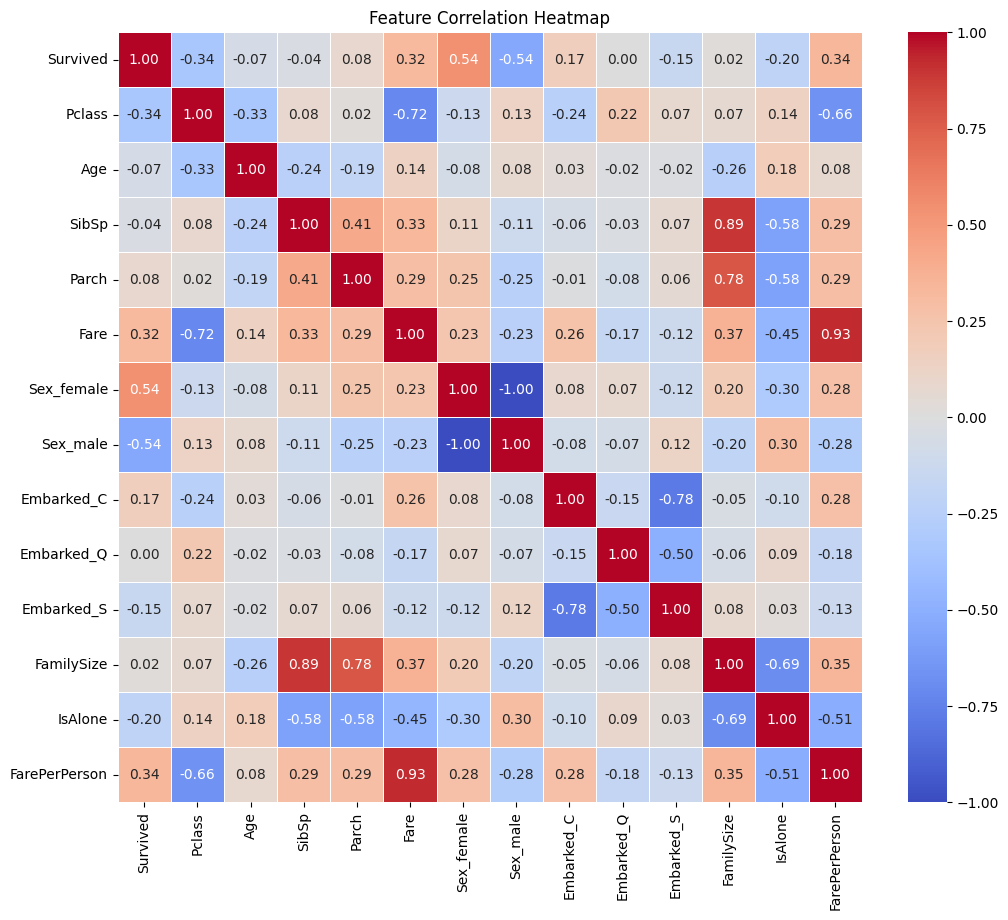

[Survived와의 상관관계]
Survived         1.000000
Sex_female       0.543351
FarePerPerson    0.343330
Fare             0.317430
Embarked_C       0.168240
Parch            0.081629
FamilySize       0.016639
Embarked_Q       0.003650
SibSp           -0.035322
Age             -0.065857
Embarked_S      -0.149683
IsAlone         -0.203367
Pclass          -0.338481
Sex_male        -0.543351
Name: Survived, dtype: float64


In [48]:
# 상관계수 행렬 계산
corr_matrix = df_train.corr()

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Survived(타겟)와의 상관관계 확인
print("[Survived와의 상관관계]")
print(corr_matrix['Survived'].sort_values(ascending=False))

## VIF(Variance Inflation Factor)를 이용한 다중 공선성 확인하기

In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF 계산을 위한 독립 변수 설정 (Target인 Survived 제외)
vif_df = df_train.drop("Survived", axis=1)

vif_data = pd.DataFrame()
vif_data["feature"] = vif_df.columns

# 각 변수별 VIF 계산
vif_data["VIF"] = [variance_inflation_factor(vif_df.values, i) 
                   for i in range(len(vif_df.columns))]

# 결과 출력 (VIF가 높은 순서대로)
print("[VIF 지수 확인]")
display(vif_data.sort_values(by="VIF", ascending=False))

c:\Users\이소영\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


[VIF 지수 확인]


,feature,VIF
2,SibSp,inf
3,Parch,inf
10,FamilySize,inf
8,Embarked_Q,1.235279e+08
7,Embarked_C,6.184341e+06
5,Sex_female,2.182937e+06
9,Embarked_S,1.871711e+05
6,Sex_male,3.216710e+03
4,Fare,1.012702e+01
12,FarePerPerson,8.497785e+00


In [50]:
# 1. 중복 정보 및 선형 결합 변수 제거
# SibSp, Parch -> FamilySize와 중복
# Sex_female -> Sex_male과 중복 (하나만 있어도 성별 판별 가능)
# Embarked_S -> C, Q가 0이면 자동으로 S이므로 중복
drop_cols = ["SibSp", "Parch", "Sex_female", "Embarked_S"]
df_refined = df_train.drop(drop_cols, axis=1)

# 2. VIF 재계산
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df_new = df_refined.drop("Survived", axis=1) # 타겟 제외
vif_data_new = pd.DataFrame()
vif_data_new["feature"] = vif_df_new.columns
vif_data_new["VIF"] = [variance_inflation_factor(vif_df_new.values, i) 
                       for i in range(len(vif_df_new.columns))]

display(vif_data_new.sort_values(by="VIF", ascending=False))

,feature,VIF
0,Pclass,14.248755
2,Fare,11.290298
8,FarePerPerson,11.022500
6,FamilySize,5.695546
7,IsAlone,4.652807
3,Sex_male,3.157078
4,Embarked_C,1.325647
5,Embarked_Q,1.200173
1,Age,1.179117


In [51]:
def reduce_vif(df, target_col="Survived", thresh=5.0):
    # 타겟 변수를 제외한 독립 변수들만 추출
    features = df.drop(columns=[target_col]).columns.tolist()
    
    while True:
        # 현재 변수들로 VIF 계산
        vif_data = pd.DataFrame()
        vif_data["feature"] = features
        vif_data["VIF"] = [variance_inflation_factor(df[features].values, i) 
                           for i in range(len(features))]
        
        # VIF 최대값 확인
        max_vif = vif_data["VIF"].max()
        if max_vif <= thresh:
            break
            
        # VIF가 가장 높은 컬럼 식별
        max_vif_column = vif_data.sort_values(by="VIF", ascending=False).iloc[0]["feature"]
        
        # 해당 컬럼 제거 및 알림
        print(f"제거된 변수: {max_vif_column} (VIF: {max_vif:.2f})")
        features.remove(max_vif_column)
    
    return df[features + [target_col]], vif_data

# 함수 실행
df_final, final_vif = reduce_vif(df_refined)

print("\n[최종 변수 목록 및 VIF]")
display(final_vif)

제거된 변수: Pclass (VIF: 14.25)
제거된 변수: FarePerPerson (VIF: 10.91)

[최종 변수 목록 및 VIF]


,feature,VIF
0,Age,1.157023
1,Fare,1.760258
2,Sex_male,2.962815
3,Embarked_C,1.240889
4,Embarked_Q,1.143348
5,FamilySize,1.691512
6,IsAlone,2.890540


# 데이터 분할

훈련 데이터와 테스트 데이터로 나누어 모델을 평가할 수 있도록 합니다.

In [52]:
from sklearn.model_selection import train_test_split

X = df_final.drop('Survived', axis=1)  # 'Survived'를 제외한 모든 feature
y = df_final['Survived']  # 타깃 변수

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 모델 활용

랜덤포레스트의 장점:
앙상블 기법이므로 과적합이 잘 일어나지 않는다.
앙상블이므로 결측치나 이상치에 강하다.
회귀 알고리즘이 아닌 의사결정나무 알고리즘에 기반한 기법이기 때문에 scaling, 정규화 과정이 필요 없다.
비선형적 데이터에 강한데, 이 역시 회귀 알고리즘이 아니라 의사결정나무이기 때문이다.
새로운 데이터가 들어와도 크게 영향을 받지 않는다.

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 랜덤 포레스트 모델 초기화
model = RandomForestClassifier(random_state=42, n_estimators=100)

# 모델 학습
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
# 테스트 세트로 예측 수행
y_pred = model.predict(X_test)

# 정확도(Accuracy) 평가
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# 분류 보고서(Classification Report) 출력
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 혼동 행렬(Confusion Matrix) 출력
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8022

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       157
           1       0.77      0.74      0.76       111

    accuracy                           0.80       268
   macro avg       0.80      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268


Confusion Matrix:
[[133  24]
 [ 29  82]]


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32336\4000073269.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='YlGnBu')


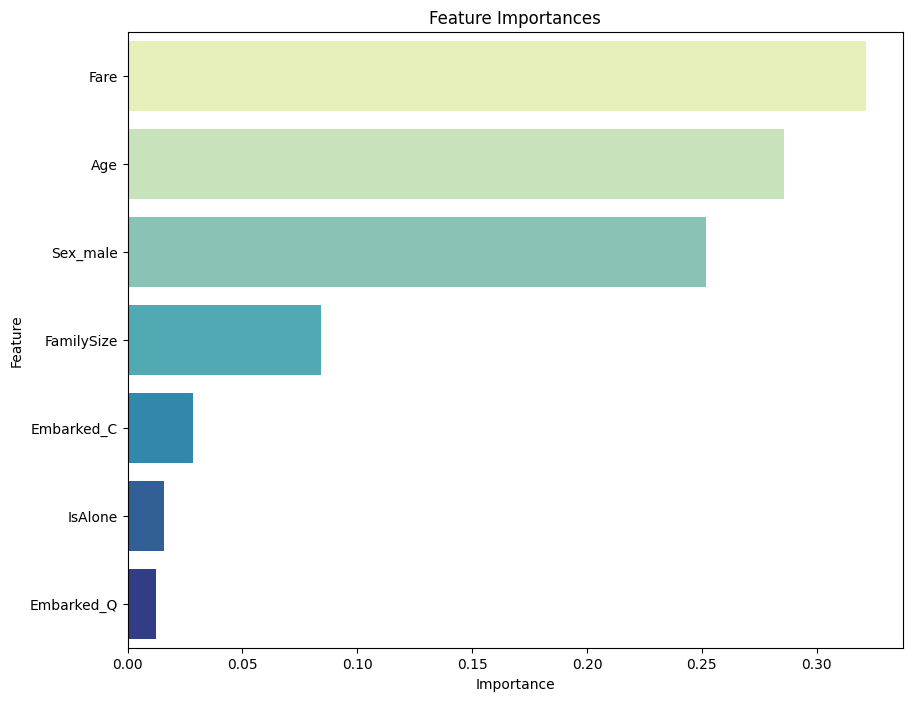

In [55]:
# 특징 중요도 추출
feature_importances = model.feature_importances_
features = X_train.columns

# 중요도 시각화
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# 중요도 순서로 정렬
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='YlGnBu')
plt.title('Feature Importances')
plt.show()

# 예측

### test 파일 전처리

훈련 데이터에 대해 수행한 스케일링, 인코딩, 컬럼 선택 등 전처리 과정은 테스트 데이터에도 동일하게 적용되어야 합니다.

In [56]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [57]:
# Age 결측치 평균값으로 대체 & Embarked 결측치 최빈값으로 대체
df_test["Age"].fillna(df_test["Age"].mean(), inplace = True)
df_test["Embarked"].fillna(df_test["Embarked"].mode()[0], inplace = True)

# Cabin 열 삭제
df_test = df_test.drop("Cabin", axis = 1)

display(df_test.head())
df_test.isnull().sum()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32336\147106638.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test["Age"].fillna(df_test["Age"].mean(), inplace = True)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32336\147106638.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
dtype: int64

In [58]:
# OneHotEncoder 사용
# get_dummies를 사용하면 어떻게 되는가?

# Encoder 객체 생성
encoder = OneHotEncoder(sparse_output=False)

# 대상 컬럼 추출 및 변환
target = ["Sex", "Embarked"]
encoded = encoder.fit_transform(df_test[target])

# 변환 데이터 DF로 만들고 컬럼명 지정
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(target))

# 기존 데이터프레임과 결합 및 원본 컬럼 삭제
df_test = pd.concat([df_test.drop(target, axis=1), encoded_df], axis=1)

display(df_test.head())
df_test.info()

,PassengerId,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,892,3,"Kelly, Mr. James",34.5,0,0,330911,7.8292,0.0,1.0,0.0,1.0,0.0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",47.0,1,0,363272,7.0000,1.0,0.0,0.0,0.0,1.0
2,894,2,"Myles, Mr. Thomas Francis",62.0,0,0,240276,9.6875,0.0,1.0,0.0,1.0,0.0
3,895,3,"Wirz, Mr. Albert",27.0,0,0,315154,8.6625,0.0,1.0,0.0,0.0,1.0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,1,1,3101298,12.2875,1.0,0.0,0.0,0.0,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Age          418 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Ticket       418 non-null    object 
 7   Fare         417 non-null    float64
 8   Sex_female   418 non-null    float64
 9   Sex_male     418 non-null    float64
 10  Embarked_C   418 non-null    float64
 11  Embarked_Q   418 non-null    float64
 12  Embarked_S   418 non-null    float64
dtypes: float64(7), int64(4), object(2)
memory usage: 42.6+ KB


In [61]:
from sklearn.preprocessing import MinMaxScaler

# 스케일러 초기화
scaler = MinMaxScaler()

# 연속형 변수만 스케일링
df_test[['Age', 'Fare']] = scaler.fit_transform(df_test[['Age', 'Fare']])

In [62]:
# 새로운 피쳐 생성

# 가족 구성원 통합
df_test['FamilySize'] = df_test['SibSp'] + df_test["Parch"] +1

# 혼자 탑승했는지의 여부
df_test['IsAlone'] = 0
df_test.loc[df_test['FamilySize'] == 1, 'IsAlone'] = 1

# 인당 요금
df_test["FarePerPerson"] = df_test["Fare"] / df_test["FamilySize"]

df_test.head()

,PassengerId,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone,FarePerPerson
0,892,3,"Kelly, Mr. James",0.452723,0,0,330911,0.015282,0.0,1.0,0.0,1.0,0.0,1,1,0.015282
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",0.617566,1,0,363272,0.013663,1.0,0.0,0.0,0.0,1.0,2,0,0.006832
2,894,2,"Myles, Mr. Thomas Francis",0.815377,0,0,240276,0.018909,0.0,1.0,0.0,1.0,0.0,1,1,0.018909
3,895,3,"Wirz, Mr. Albert",0.353818,0,0,315154,0.016908,0.0,1.0,0.0,0.0,1.0,1,1,0.016908
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",0.287881,1,1,3101298,0.023984,1.0,0.0,0.0,0.0,1.0,3,0,0.007995


In [64]:
test = df_test.reindex(columns=X_train.columns, fill_value=0)

# 2. 모델을 사용하여 예측
y_pred_test = model.predict(test)

# 3. 예측 결과를 test 데이터프레임에 추가
test['Survived'] = y_pred_test

# 예측된 survived 값을 확인
print(test[['Survived']])

     Survived
0           0
1           1
2           0
3           0
4           1
..        ...
413         0
414         1
415         0
416         0
417         0

[418 rows x 1 columns]


In [65]:
test['Survived'].value_counts()

Survived
0    240
1    178
Name: count, dtype: int64